# Rep 1 / One-Network Latent Probe

This notebook focuses on the surprising `repeat=1, train_networks=1` AE-only case from `04c`.

Goal: train the same first-frame autoencoder setup, then ask what the latent space is actually correlating with.

The probe keeps `repeat=1` and `train_networks=1`, evaluates a small grid of latent sizes and frame counts, and exports:
- first-frame latent correlations to final p-ratio, stiffness, geometry, and train-distance descriptors
- validation-fit readout performance on test networks
- descriptor-only baselines for final p-ratio
- permutation/null checks for whether the observed latent correlation is unusual
- trajectory-progress latent correlations to detect dynamic/progress leakage


In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

from graph_utils import calc_p_ratio_rollout_sides
from course_project.data import load_dataset
from course_project.models.latent_space_simulator import NodeDeltaAttentionAutoEncoder
from course_project.utils import resolve_device

plt.rcParams['figure.dpi'] = 120


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)

latent_dims = [1, 2, 4]
train_counts = [1]
train_frame_counts = [1, 2, 4]
repeat_indices = [1]

cfg = {
    'dataset_path': '../data/new_reid_combined.pt',
    'val_count': 25,
    'latent_dim': 1,  # overwritten by latent_dims during the focused probe
    'latent_tokens': 12,
    'hidden_size': 128,
    'pos_dim': 2,
    'batch_graphs': 8,
    'frame_skip': 15,
    'near_zero_stiffness_threshold': 1e-3,
    'progress_eval_max_frames': 20,
    'progress_eval_max_sims': 40,
    'ae_max_epochs': 80,
    'ae_patience': 25,
    'ae_lr': 1e-3,
    'ae_weight_decay': 1e-5,
    'early_stop_min_delta': 1e-5,
    'node_feature_mode': 'delta',
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'device': 'auto',
    'output_root': 'results/rep1_net1_latent_probe',
    'null_permutations': 1000,
}


def resolve_existing_path(path_like):
    path = Path(path_like)
    if path.exists():
        return str(path)
    if str(path).startswith('../'):
        repo_relative_path = Path(str(path)[3:])
        if repo_relative_path.exists():
            return str(repo_relative_path)
    return str(path)

cfg['dataset_path'] = resolve_existing_path(cfg['dataset_path'])
device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root'])
run_dir.mkdir(parents=True, exist_ok=True)
print('device:', device)
print('output:', run_dir)
display(pd.DataFrame([cfg]))


run seed: 2065626611
device: cuda
output: results/rep1_net1_latent_probe


,dataset_path,val_count,latent_dim,latent_tokens,hidden_size,pos_dim,batch_graphs,frame_skip,near_zero_stiffness_threshold,progress_eval_max_frames,...,ae_patience,ae_lr,ae_weight_decay,early_stop_min_delta,node_feature_mode,split_seed,shuffle_dataset_within_source,device,output_root,null_permutations
0,../data/new_reid_combined.pt,25,1,12,128,2,8,15,0.001,20,...,25,0.001,0.00001,0.00001,delta,2065626611,True,auto,results/rep1_net1_latent_probe,1000


In [3]:
def filtered_frame_ids(sim, *, include_last=False, max_frames=None):
    stop = len(sim) if include_last else len(sim) - 1
    step = max(1, int(cfg.get('frame_skip', 1)))
    frame_ids = list(range(0, max(stop, 0), step))
    if max_frames is not None:
        frame_ids = frame_ids[:int(max_frames)]
    return [int(t) for t in frame_ids]


def make_frame_index(sims, *, max_frames_per_sim=None, include_last=True):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=include_last, max_frames=max_frames_per_sim)
        rows.extend((sim_idx, int(t)) for t in frame_ids)
    return rows


def iter_batches(rows, batch_graphs, *, shuffle=True):
    rows = list(rows)
    if shuffle:
        random.shuffle(rows)
    for i in range(0, len(rows), int(batch_graphs)):
        yield rows[i:i + int(batch_graphs)]


def pearson_r(a, b):
    a = pd.Series(a, dtype=float)
    b = pd.Series(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3 or np.isclose(a[mask].std(), 0.0) or np.isclose(b[mask].std(), 0.0):
        return float('nan')
    return float(a[mask].corr(b[mask]))


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return float('nan')
    y = y_true[mask]
    pred = y_pred[mask]
    ss_res = float(np.sum((y - pred) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')


def linear_fit_on_val_eval_test(val_df, test_df, x_col, y_col='final_p_ratio'):
    val_pair = val_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    test_pair = test_df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(val_pair) < 2 or len(test_pair) < 2 or np.isclose(val_pair[x_col].std(), 0.0):
        return float('nan')
    coef = np.polyfit(val_pair[x_col].to_numpy(dtype=float), val_pair[y_col].to_numpy(dtype=float), deg=1)
    pred = coef[0] * test_pair[x_col].to_numpy(dtype=float) + coef[1]
    return r2_score(test_pair[y_col], pred)


def linear_combo_fit_on_val_eval_test(val_df, test_df, feature_cols, y_col='final_p_ratio'):
    cols = list(feature_cols)
    val_pair = val_df[cols + [y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    test_pair = test_df[cols + [y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(cols) == 0 or len(val_pair) < len(cols) + 1 or len(test_pair) < 3:
        return {
            'test_r': float('nan'),
            'test_corr_r2': float('nan'),
            'test_val_fit_r2': float('nan'),
            'intercept': float('nan'),
            'coefficients': {},
            'n_val': int(len(val_pair)),
            'n_test': int(len(test_pair)),
        }
    X_val = val_pair[cols].to_numpy(dtype=float)
    y_val = val_pair[y_col].to_numpy(dtype=float)
    X_test = test_pair[cols].to_numpy(dtype=float)
    y_test = test_pair[y_col].to_numpy(dtype=float)
    if np.linalg.matrix_rank(np.column_stack([np.ones(len(X_val)), X_val])) < 2:
        return {
            'test_r': float('nan'),
            'test_corr_r2': float('nan'),
            'test_val_fit_r2': float('nan'),
            'intercept': float('nan'),
            'coefficients': {},
            'n_val': int(len(val_pair)),
            'n_test': int(len(test_pair)),
        }
    X_design = np.column_stack([np.ones(len(X_val)), X_val])
    coef = np.linalg.lstsq(X_design, y_val, rcond=None)[0]
    pred = np.column_stack([np.ones(len(X_test)), X_test]) @ coef
    test_r = pearson_r(pred, y_test)
    return {
        'test_r': test_r,
        'test_corr_r2': test_r * test_r if np.isfinite(test_r) else np.nan,
        'test_val_fit_r2': r2_score(y_test, pred),
        'intercept': float(coef[0]),
        'coefficients': {col: float(value) for col, value in zip(cols, coef[1:])},
        'n_val': int(len(val_pair)),
        'n_test': int(len(test_pair)),
    }


In [4]:
def edge_features(ref_graph, cur_graph, *, device):
    ref_e = ref_graph.edge_attr.to(device).float()
    cur_e = cur_graph.edge_attr.to(device).float()
    ref_vec = ref_e[:, :cfg['pos_dim']]
    cur_vec = cur_e[:, :cfg['pos_dim']]
    ref_len = ref_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    cur_len = cur_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    stiffness = ref_e[:, -1:]
    stretch = cur_len - ref_len
    rel_stretch = stretch / ref_len.clamp_min(1e-6)
    return torch.cat([ref_vec, cur_vec, ref_len, cur_len, stretch, rel_stretch, stiffness, cur_e], dim=-1)


def frame_node_feature(sim, t, *, mode, device):
    t = int(t)
    cur_pos = sim[t].x[:, :cfg['pos_dim']].to(device).float()
    if mode in ('position', 'positions'):
        return cur_pos
    if mode == 'delta':
        ref_pos = sim[0].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - ref_pos
    if mode == 'velocity':
        if t <= 0:
            return torch.zeros_like(cur_pos)
        prev_pos = sim[t - 1].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - prev_pos
    raise ValueError(f'Unknown node_feature_mode: {mode}')


def batch_delta_graphs(sims, rows, *, device, node_feature_mode='delta'):
    deltas = []
    node_features = []
    ref_positions = []
    edge_attrs = []
    ref_edge_attrs = []
    edge_indices = []
    batch = []
    node_offset = 0
    for local_idx, (sim_idx, t) in enumerate(rows):
        sim = sims[int(sim_idx)]
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        cur_pos = cur_graph.x[:, :cfg['pos_dim']].to(device).float()
        deltas.append(cur_pos - ref_pos)
        node_features.append(frame_node_feature(sim, t, mode=node_feature_mode, device=device))
        ref_positions.append(ref_pos)
        edge_attrs.append(edge_features(ref_graph, cur_graph, device=device))
        ref_edge_attrs.append(edge_features(ref_graph, ref_graph, device=device))
        edge_indices.append(ref_graph.edge_index.to(device).long() + node_offset)
        batch.append(torch.full((ref_pos.size(0),), local_idx, dtype=torch.long, device=device))
        node_offset += ref_pos.size(0)
    return {
        'delta': torch.cat(deltas, dim=0),
        'node_feature': torch.cat(node_features, dim=0),
        'ref_pos': torch.cat(ref_positions, dim=0),
        'edge_attr': torch.cat(edge_attrs, dim=0),
        'ref_edge_attr': torch.cat(ref_edge_attrs, dim=0),
        'edge_index': torch.cat(edge_indices, dim=1),
        'batch': torch.cat(batch, dim=0),
    }


def fit_tensor_stats(chunks):
    values = torch.cat(chunks, dim=0)
    mean = values.mean(dim=0, keepdim=True)
    std = values.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def fit_stats(sims, frame_rows):
    delta_chunks = []
    node_feature_chunks = []
    edge_chunks = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=cfg['node_feature_mode'])
        delta_chunks.append(batch_data['delta'])
        node_feature_chunks.append(batch_data['node_feature'])
        edge_chunks.append(batch_data['edge_attr'])
        edge_chunks.append(batch_data['ref_edge_attr'])
    delta_mean, delta_std = fit_tensor_stats(delta_chunks)
    node_feature_mean, node_feature_std = fit_tensor_stats(node_feature_chunks)
    edge_mean, edge_std = fit_tensor_stats(edge_chunks)
    return {
        'delta_mean': delta_mean,
        'delta_std': delta_std,
        'node_feature_mean': node_feature_mean,
        'node_feature_std': node_feature_std,
        'edge_mean': edge_mean,
        'edge_std': edge_std,
    }


def normalize(x, mean, std):
    return (x - mean.to(x.device)) / std.to(x.device)


In [5]:
def resolve_dataset_splits_with_indices(dataset_path, *, train_count, val_count, split_seed, shuffle_within_source):
    sims = load_dataset(dataset_path)
    indexed = list(enumerate(sims))
    if shuffle_within_source:
        generator = torch.Generator()
        generator.manual_seed(0 if split_seed is None else int(split_seed))
        order = torch.randperm(len(indexed), generator=generator).tolist()
        indexed = [indexed[i] for i in order]
    train_count = int(train_count)
    val_count = int(val_count)
    train_items = indexed[:train_count]
    val_items = indexed[train_count:train_count + val_count]
    test_items = indexed[train_count + val_count:]
    split_info = [{
        'source': Path(dataset_path).stem,
        'path': str(dataset_path),
        'total': len(indexed),
        'train': len(train_items),
        'val': len(val_items),
        'test': len(test_items),
        'train_original_indices': ','.join(str(i) for i, _ in train_items),
    }]
    return train_items, val_items, test_items, split_info


def _unique_initial_edges(graph):
    pos = graph.x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_attr = graph.edge_attr.detach().cpu().float().numpy()
    pair_rows = {}
    for e in range(edge_index.shape[1]):
        i, j = int(edge_index[0, e]), int(edge_index[1, e])
        if i == j:
            continue
        key = (i, j) if i < j else (j, i)
        if key in pair_rows:
            continue
        vec = pos[j] - pos[i]
        length = float(np.linalg.norm(vec))
        stiffness = float(edge_attr[e, -1]) if edge_attr.size else np.nan
        pair_rows[key] = {'i': key[0], 'j': key[1], 'vec': vec, 'length': length, 'stiffness': stiffness}
    return list(pair_rows.values())


def _safe_mean(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)) if values.size and np.isfinite(values).any() else np.nan


def _safe_std(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanstd(values)) if values.size and np.isfinite(values).any() else np.nan


def _safe_min(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmin(values)) if values.size and np.isfinite(values).any() else np.nan


def _safe_max(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmax(values)) if values.size and np.isfinite(values).any() else np.nan


def initial_descriptor_row(sim, sim_idx, *, split, original_sim_idx=None):
    graph0 = sim[0]
    pos = graph0.x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    edges = _unique_initial_edges(graph0)
    stiffness = np.asarray([edge['stiffness'] for edge in edges], dtype=float)
    lengths = np.asarray([edge['length'] for edge in edges], dtype=float)
    near_zero_threshold = float(cfg.get('near_zero_stiffness_threshold', 1e-3))
    near_zero_count = int((np.abs(stiffness) <= near_zero_threshold).sum()) if stiffness.size else 0
    horizontal = []
    vertical = []
    diagonal = []
    horizontal_lengths = []
    vertical_lengths = []
    diagonal_lengths = []
    for edge in edges:
        if edge['length'] <= 1e-12:
            continue
        unit = edge['vec'] / edge['length']
        if abs(float(unit[0])) >= 0.85:
            horizontal.append(edge['stiffness'])
            horizontal_lengths.append(edge['length'])
        elif abs(float(unit[1])) >= 0.85:
            vertical.append(edge['stiffness'])
            vertical_lengths.append(edge['length'])
        else:
            diagonal.append(edge['stiffness'])
            diagonal_lengths.append(edge['length'])
    span = np.nanmax(pos, axis=0) - np.nanmin(pos, axis=0) if pos.size else np.full(cfg['pos_dim'], np.nan)
    edge_count = int(len(edges))
    row = {
        'split': split,
        'sim_idx': int(sim_idx),
        'original_sim_idx': int(original_sim_idx) if original_sim_idx is not None else int(sim_idx),
        'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
        'node_count': int(pos.shape[0]),
        'edge_count': edge_count,
        'bbox_x_span': float(span[0]) if len(span) >= 1 else np.nan,
        'bbox_y_span': float(span[1]) if len(span) >= 2 else np.nan,
        'bbox_aspect_y_over_x': float(span[1] / span[0]) if len(span) >= 2 and abs(span[0]) > 1e-12 else np.nan,
        'edge_length_mean': _safe_mean(lengths),
        'edge_length_std': _safe_std(lengths),
        'edge_length_min': _safe_min(lengths),
        'edge_length_max': _safe_max(lengths),
        'stiffness_mean': _safe_mean(stiffness),
        'stiffness_std': _safe_std(stiffness),
        'stiffness_min': _safe_min(stiffness),
        'stiffness_max': _safe_max(stiffness),
        'near_zero_stiffness_threshold': near_zero_threshold,
        'near_zero_stiffness_edge_count': near_zero_count,
        'near_zero_stiffness_edge_fraction': float(near_zero_count / edge_count) if edge_count else np.nan,
        'horizontal_edge_fraction': float(len(horizontal) / edge_count) if edge_count else np.nan,
        'vertical_edge_fraction': float(len(vertical) / edge_count) if edge_count else np.nan,
        'diagonal_edge_fraction': float(len(diagonal) / edge_count) if edge_count else np.nan,
        'horizontal_stiffness': _safe_mean(horizontal),
        'vertical_stiffness': _safe_mean(vertical),
        'diagonal_stiffness': _safe_mean(diagonal),
        'horizontal_length_mean': _safe_mean(horizontal_lengths),
        'vertical_length_mean': _safe_mean(vertical_lengths),
        'diagonal_length_mean': _safe_mean(diagonal_lengths),
    }
    row['vertical_minus_horizontal_stiffness'] = row['vertical_stiffness'] - row['horizontal_stiffness']
    row['vertical_over_horizontal_stiffness'] = row['vertical_stiffness'] / row['horizontal_stiffness'] if np.isfinite(row['horizontal_stiffness']) and abs(row['horizontal_stiffness']) > 1e-12 else np.nan
    return row


def descriptor_columns(df):
    excluded = {'split', 'sim_idx', 'original_sim_idx'}
    z_cols = {c for c in df.columns if c.startswith('z')}
    return [c for c in df.columns if c not in excluded and c not in z_cols and pd.api.types.is_numeric_dtype(df[c])]


def add_train_reference_distances(df, train_descriptor_df):
    if train_descriptor_df.empty:
        return df
    out = df.copy()
    descriptor_cols = [c for c in descriptor_columns(out) if c in train_descriptor_df.columns and c != 'final_p_ratio']
    train_row = train_descriptor_df.iloc[0]
    for col in descriptor_cols:
        out[f'delta_to_train_{col}'] = out[col] - float(train_row[col])
    finite_cols = [c for c in descriptor_cols if out[c].notna().any() and np.isfinite(float(train_row[c]))]
    if finite_cols:
        train_vec = train_row[finite_cols].astype(float).to_numpy()
        mat = out[finite_cols].astype(float).to_numpy()
        scale = np.nanstd(mat, axis=0)
        scale = np.where(np.isfinite(scale) & (scale > 1e-12), scale, 1.0)
        out['descriptor_distance_to_train'] = np.sqrt(np.nanmean(((mat - train_vec) / scale) ** 2, axis=1))
    out['final_p_ratio_delta_to_train'] = out['final_p_ratio'] - float(train_row['final_p_ratio'])
    return out


In [6]:
def ae_epoch(model, sims, frame_rows, stats, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=is_train):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=cfg['node_feature_mode'])
        delta_norm = normalize(batch_data['delta'], stats['delta_mean'], stats['delta_std'])
        node_feature_norm = normalize(batch_data['node_feature'], stats['node_feature_mean'], stats['node_feature_std'])
        edge_attr_norm = normalize(batch_data['edge_attr'], stats['edge_mean'], stats['edge_std'])
        ref_edge_attr_norm = normalize(batch_data['ref_edge_attr'], stats['edge_mean'], stats['edge_std'])
        recon_norm, _ = model(
            node_feature_norm,
            batch_data['ref_pos'],
            edge_attr_norm,
            ref_edge_attr_norm,
            batch_data['edge_index'],
            batch_data['batch'],
        )
        loss = F.mse_loss(recon_norm, delta_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')


def encode_frame(model, sim, t, stats):
    model.eval()
    with torch.no_grad():
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        node_feature = frame_node_feature(sim, t, mode=cfg['node_feature_mode'], device=device)
        edge_attr = edge_features(ref_graph, cur_graph, device=device)
        ref_edge_attr = edge_features(ref_graph, ref_graph, device=device)
        batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
        z, _ = model.encode(
            normalize(node_feature, stats['node_feature_mean'], stats['node_feature_std']),
            ref_pos,
            normalize(edge_attr, stats['edge_mean'], stats['edge_std']),
            normalize(ref_edge_attr, stats['edge_mean'], stats['edge_std']),
            ref_graph.edge_index.to(device).long(),
            batch,
        )
    return z.squeeze(0).detach().cpu().numpy()


def first_frame_latent_table(model, sim_items, stats, *, split, train_descriptor_df=None):
    rows = []
    for sim_idx, item in enumerate(sim_items):
        original_sim_idx, sim = item if isinstance(item, tuple) and len(item) == 2 else (sim_idx, item)
        row = initial_descriptor_row(sim, sim_idx, split=split, original_sim_idx=original_sim_idx)
        z = encode_frame(model, sim, 0, stats)
        for dim_idx, value in enumerate(z):
            row[f'z{dim_idx}'] = float(value)
        rows.append(row)
    df = pd.DataFrame(rows)
    if train_descriptor_df is not None and split != 'train':
        df = add_train_reference_distances(df, train_descriptor_df)
    return df


def trajectory_progress_latent_table(model, sim_items, stats, *, split, max_sims=None, max_frames=None):
    rows = []
    eval_items = sim_items[:int(max_sims)] if max_sims is not None else sim_items
    for sim_idx, item in enumerate(eval_items):
        original_sim_idx, sim = item if isinstance(item, tuple) and len(item) == 2 else (sim_idx, item)
        frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=max_frames)
        frame_count = len(frame_ids)
        final_p_ratio = float(calc_p_ratio_rollout_sides(sim, -1))
        for frame_order, frame_idx in enumerate(frame_ids):
            z = encode_frame(model, sim, int(frame_idx), stats)
            row = {
                'split': split,
                'sim_idx': int(sim_idx),
                'original_sim_idx': int(original_sim_idx),
                'frame': int(frame_idx),
                'frame_order': int(frame_order),
                'frame_frac': float(frame_order / max(frame_count - 1, 1)),
                'final_p_ratio': final_p_ratio,
            }
            for dim_idx, value in enumerate(z):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
    return pd.DataFrame(rows)


In [7]:
def train_autoencoder_case(latent_dim, train_count, train_frames, repeat_idx):
    repeat_seed = int(cfg['split_seed']) + 1009 * int(repeat_idx) + 7919 * int(latent_dim) + 9173 * int(train_count) + 101 * int(train_frames)
    random.seed(repeat_seed)
    np.random.seed(repeat_seed)
    torch.manual_seed(repeat_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(repeat_seed)

    train_items, val_items, test_items, split_info = resolve_dataset_splits_with_indices(
        cfg['dataset_path'],
        train_count=int(train_count),
        val_count=int(cfg['val_count']),
        split_seed=repeat_seed,
        shuffle_within_source=cfg.get('shuffle_dataset_within_source', False),
    )
    train_data = [sim for _, sim in train_items]
    val_data = [sim for _, sim in val_items]
    frame_rows = make_frame_index(train_data, max_frames_per_sim=int(train_frames), include_last=True)
    val_frame_rows = make_frame_index(val_data, max_frames_per_sim=4, include_last=True)
    stats = fit_stats(train_data, frame_rows)
    edge_dim = int(stats['edge_mean'].numel())

    model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'],
        edge_dim=edge_dim,
        hidden_size=cfg['hidden_size'],
        latent_dim=int(latent_dim),
        latent_tokens=cfg['latent_tokens'],
    ).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['ae_lr'], weight_decay=cfg['ae_weight_decay'])
    best_state = None
    best_val = float('inf')
    stale = 0
    history = []
    label = f'CV{latent_dim} | repeat={repeat_idx} | nets={train_count} | frames={train_frames}'
    for epoch in range(1, int(cfg['ae_max_epochs']) + 1):
        train_loss = ae_epoch(model, train_data, frame_rows, stats, optimizer=opt)
        with torch.no_grad():
            val_loss = ae_epoch(model, val_data, val_frame_rows, stats, optimizer=None)
        history.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'seed': int(repeat_seed),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'epoch': epoch,
            'train_mse_norm': train_loss,
            'val_mse_norm': val_loss,
        })
        if val_loss < best_val - cfg['early_stop_min_delta']:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f'{label} ae {epoch:03d} train={train_loss:.5g} val={val_loss:.5g} stale={stale}')
        if stale >= int(cfg['ae_patience']):
            break
    model.load_state_dict(best_state)
    model.eval()

    train_latents = first_frame_latent_table(model, train_items, stats, split='train')
    train_descriptor_df = train_latents.drop(columns=[c for c in train_latents.columns if c.startswith('z')], errors='ignore')
    val_latents = first_frame_latent_table(model, val_items, stats, split='val', train_descriptor_df=train_descriptor_df)
    test_latents = first_frame_latent_table(model, test_items, stats, split='test', train_descriptor_df=train_descriptor_df)
    progress_latents = trajectory_progress_latent_table(
        model,
        test_items,
        stats,
        split='test',
        max_sims=cfg.get('progress_eval_max_sims'),
        max_frames=cfg.get('progress_eval_max_frames'),
    )
    for df in [train_latents, val_latents, test_latents, progress_latents]:
        df['latent_dim'] = int(latent_dim)
        df['repeat'] = int(repeat_idx)
        df['seed'] = int(repeat_seed)
        df['train_networks'] = int(train_count)
        df['train_frames_per_network'] = int(train_frames)
    history_df = pd.DataFrame(history)
    return {
        'label': label,
        'latent_dim': int(latent_dim),
        'repeat': int(repeat_idx),
        'seed': int(repeat_seed),
        'train_networks': int(train_count),
        'train_frames_per_network': int(train_frames),
        'split_info': split_info,
        'history': history_df,
        'train_latents': train_latents,
        'val_latents': val_latents,
        'test_latents': test_latents,
        'progress_latents': progress_latents,
        'best_val_mse_norm': best_val,
    }


In [ ]:
ae_results = []
for latent_dim in latent_dims:
    for repeat_idx in repeat_indices:
        for train_count in train_counts:
            for train_frames in train_frame_counts:
                print(f'\n### AE-only probe: CV{latent_dim}, repeat={repeat_idx}, networks={train_count}, frames={train_frames}')
                ae_results.append(train_autoencoder_case(latent_dim, train_count, train_frames, repeat_idx))
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

all_history_df = pd.concat([r['history'] for r in ae_results], ignore_index=True)
first_frame_latent_df = pd.concat(
    [r['train_latents'] for r in ae_results] + [r['val_latents'] for r in ae_results] + [r['test_latents'] for r in ae_results],
    ignore_index=True,
)
trajectory_progress_latent_df = pd.concat([r['progress_latents'] for r in ae_results], ignore_index=True)
split_info_df = pd.DataFrame([row | {
    'latent_dim': r['latent_dim'],
    'repeat': r['repeat'],
    'train_networks': r['train_networks'],
    'train_frames_per_network': r['train_frames_per_network'],
} for r in ae_results for row in r['split_info']])
best_history_df = (
    all_history_df
    .groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'])['val_mse_norm']
    .min()
    .reset_index()
)
display(split_info_df)
display(best_history_df.round(6))
display(first_frame_latent_df.head().round(4))
display(trajectory_progress_latent_df.head().round(4))



### AE-only probe: CV1, repeat=1, networks=1, frames=1
CV1 | repeat=1 | nets=1 | frames=1 ae 001 train=0.0008448 val=2.4253e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 007 train=0.00011799 val=2.4253e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 008 train=5.1905e-05 val=2.4253e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 009 train=1.657e-05 val=2.4253e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 010 train=1.1049e-05 val=2.4252e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 011 train=1.8305e-05 val=2.4252e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 017 train=8.1227e-06 val=2.4252e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 018 train=1.1948e-05 val=2.4252e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 019 train=1.3002e-05 val=2.4252e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 020 train=1.0238e-05 val=2.4252e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 021 train=5.8824e-06 val=2.4251e+06 stale=0
CV1 | repeat=1 | nets=1 | frames=1 ae 022 tr

In [ ]:
base_targets = [
    'final_p_ratio',
    'stiffness_mean',
    'stiffness_std',
    'stiffness_min',
    'stiffness_max',
    'near_zero_stiffness_edge_count',
    'near_zero_stiffness_edge_fraction',
    'horizontal_stiffness',
    'vertical_stiffness',
    'diagonal_stiffness',
    'vertical_minus_horizontal_stiffness',
    'vertical_over_horizontal_stiffness',
    'horizontal_edge_fraction',
    'vertical_edge_fraction',
    'diagonal_edge_fraction',
    'edge_length_mean',
    'edge_length_std',
    'bbox_x_span',
    'bbox_y_span',
    'bbox_aspect_y_over_x',
    'descriptor_distance_to_train',
    'final_p_ratio_delta_to_train',
]
targets = [c for c in base_targets if c in first_frame_latent_df.columns]

corr_rows = []
for (latent_dim, repeat_idx, train_count, train_frames, split), group in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network', 'split'], sort=False):
    z_cols = [col for col in group.columns if col.startswith('z')]
    for z_col in z_cols:
        for target in targets:
            if target not in group.columns or group[target].nunique(dropna=True) < 2:
                continue
            r = pearson_r(group[z_col], group[target])
            corr_rows.append({
                'latent_dim': int(latent_dim),
                'repeat': int(repeat_idx),
                'train_networks': int(train_count),
                'train_frames_per_network': int(train_frames),
                'split': split,
                'signal': z_col,
                'target': target,
                'pearson_r': r,
                'corr_r2': r * r if np.isfinite(r) else np.nan,
                'n': int(group[[z_col, target]].dropna().shape[0]),
            })

# Descriptor-only baseline: which initial descriptors already correlate with final p-ratio?
for (latent_dim, repeat_idx, train_count, train_frames, split), group in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network', 'split'], sort=False):
    for descriptor in [c for c in targets if c != 'final_p_ratio']:
        if descriptor not in group.columns or group[descriptor].nunique(dropna=True) < 2:
            continue
        r = pearson_r(group[descriptor], group['final_p_ratio'])
        corr_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'split': split,
            'signal': descriptor,
            'target': 'final_p_ratio',
            'pearson_r': r,
            'corr_r2': r * r if np.isfinite(r) else np.nan,
            'n': int(group[[descriptor, 'final_p_ratio']].dropna().shape[0]),
        })

corr_df = pd.DataFrame(corr_rows)

readout_rows = []
for (latent_dim, repeat_idx, train_count, train_frames), _ in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'], sort=False):
    val_df = first_frame_latent_df[
        first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        & first_frame_latent_df['split'].eq('val')
    ]
    test_df = first_frame_latent_df[
        first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        & first_frame_latent_df['split'].eq('test')
    ]
    z_cols = [c for c in test_df.columns if c.startswith('z')]
    for z_col in z_cols:
        readout_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'signal': z_col,
            'val_final_p_ratio_r': pearson_r(val_df[z_col], val_df['final_p_ratio']),
            'test_final_p_ratio_r': pearson_r(test_df[z_col], test_df['final_p_ratio']),
            'test_final_p_ratio_corr_r2': pearson_r(test_df[z_col], test_df['final_p_ratio']) ** 2,
            'test_final_p_ratio_val_fit_r2': linear_fit_on_val_eval_test(val_df, test_df, z_col),
        })
readout_summary_df = pd.DataFrame(readout_rows)

linear_combo_rows = []
for (latent_dim, repeat_idx, train_count, train_frames), _ in first_frame_latent_df.groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'], sort=False):
    val_df = first_frame_latent_df[
        first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        & first_frame_latent_df['split'].eq('val')
    ]
    test_df = first_frame_latent_df[
        first_frame_latent_df['latent_dim'].eq(latent_dim)
        & first_frame_latent_df['repeat'].eq(repeat_idx)
        & first_frame_latent_df['train_networks'].eq(train_count)
        & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        & first_frame_latent_df['split'].eq('test')
    ]
    z_cols = sorted([c for c in test_df.columns if c.startswith('z')], key=lambda c: int(c[1:]))
    combo = linear_combo_fit_on_val_eval_test(val_df, test_df, z_cols)
    row = {
        'latent_dim': int(latent_dim),
        'repeat': int(repeat_idx),
        'train_networks': int(train_count),
        'train_frames_per_network': int(train_frames),
        'signal': 'z_linear_combo_val_fit',
        'features': ','.join(z_cols),
        'test_final_p_ratio_r': combo['test_r'],
        'test_final_p_ratio_corr_r2': combo['test_corr_r2'],
        'test_final_p_ratio_val_fit_r2': combo['test_val_fit_r2'],
        'intercept': combo['intercept'],
        'n_val': combo['n_val'],
        'n_test': combo['n_test'],
    }
    for col in z_cols:
        row[f'coef_{col}'] = combo['coefficients'].get(col, np.nan)
    linear_combo_rows.append(row)

linear_combo_readout_df = pd.DataFrame(linear_combo_rows)

display(readout_summary_df.sort_values('test_final_p_ratio_corr_r2', ascending=False).round(4))
display(linear_combo_readout_df.sort_values('test_final_p_ratio_corr_r2', ascending=False).round(4))
display(
    corr_df[corr_df['split'].eq('test')]
    .sort_values('corr_r2', ascending=False)
    .head(40)
    .round(4)
)


,latent_dim,repeat,train_networks,train_frames_per_network,signal,val_final_p_ratio_r,test_final_p_ratio_r,test_final_p_ratio_corr_r2,test_final_p_ratio_val_fit_r2
25,4,1,1,1,z1,0.8430,0.8568,0.7341,0.7311
27,4,1,1,1,z3,-0.8755,-0.8497,0.7220,0.7027
24,4,1,1,1,z0,-0.8428,-0.8493,0.7214,0.7140
35,4,1,1,4,z3,-0.8685,-0.8374,0.7012,0.6255
34,4,1,1,4,z2,-0.8508,-0.8084,0.6535,0.5816
32,4,1,1,4,z0,0.8444,0.8039,0.6463,0.5675
12,2,1,1,1,z0,0.9175,0.7886,0.6218,0.5582
33,4,1,1,4,z1,0.8344,0.7787,0.6064,0.5275
31,4,1,1,2,z3,-0.8298,-0.7506,0.5635,0.5483
8,1,1,1,4,z0,0.7183,0.7503,0.5629,0.5611


,latent_dim,repeat,train_networks,train_frames_per_network,split,signal,target,pearson_r,corr_r2,n
1961,4,1,1,4,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1919,4,1,1,1,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1877,2,1,1,2,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1856,2,1,1,1,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1835,1,1,1,4,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1793,1,1,1,1,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1940,4,1,1,2,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1814,1,1,1,2,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1898,2,1,1,4,test,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,76
1563,4,1,1,4,test,z3,stiffness_mean,0.9633,0.9279,76


In [ ]:
def permutation_corr_null(x, y, *, n_perm=1000, seed=0):
    pair = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 4 or pair['x'].nunique() < 2 or pair['y'].nunique() < 2:
        return {'observed_r': np.nan, 'abs_observed_r': np.nan, 'null_abs_r_mean': np.nan, 'null_abs_r_p95': np.nan, 'empirical_p': np.nan, 'n': int(len(pair))}
    rng = np.random.default_rng(seed)
    x_arr = pair['x'].to_numpy(dtype=float)
    y_arr = pair['y'].to_numpy(dtype=float)
    observed = pearson_r(x_arr, y_arr)
    null = []
    for _ in range(int(n_perm)):
        null.append(abs(pearson_r(x_arr, rng.permutation(y_arr))))
    null = np.asarray(null, dtype=float)
    return {
        'observed_r': observed,
        'abs_observed_r': abs(observed) if np.isfinite(observed) else np.nan,
        'null_abs_r_mean': float(np.nanmean(null)),
        'null_abs_r_p95': float(np.nanpercentile(null, 95)),
        'empirical_p': float((np.sum(null >= abs(observed)) + 1) / (len(null) + 1)) if np.isfinite(observed) else np.nan,
        'n': int(len(pair)),
    }


def residualize(y, controls):
    y = np.asarray(y, dtype=float)
    X = np.asarray(controls, dtype=float)
    if X.ndim == 1:
        X = X[:, None]
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    resid = np.full_like(y, np.nan, dtype=float)
    if mask.sum() < X.shape[1] + 2:
        return resid
    X_design = np.column_stack([np.ones(mask.sum()), X[mask]])
    coef = np.linalg.lstsq(X_design, y[mask], rcond=None)[0]
    resid[mask] = y[mask] - X_design @ coef
    return resid


null_rows = []
partial_rows = []
control_sets = {
    'stiffness_std': ['stiffness_std'],
    'near_zero_fraction': ['near_zero_stiffness_edge_fraction'],
    'geometry_spans': ['bbox_x_span', 'bbox_y_span', 'edge_length_mean', 'edge_length_std'],
    'train_distance': ['descriptor_distance_to_train'],
    'stiffness_plus_geometry': ['stiffness_std', 'near_zero_stiffness_edge_fraction', 'bbox_x_span', 'bbox_y_span', 'edge_length_mean', 'edge_length_std'],
}
for key, group in first_frame_latent_df[first_frame_latent_df['split'].eq('test')].groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'], sort=False):
    latent_dim, repeat_idx, train_count, train_frames = key
    z_cols = [c for c in group.columns if c.startswith('z')]
    for z_col in z_cols:
        null_stats = permutation_corr_null(group[z_col], group['final_p_ratio'], n_perm=cfg['null_permutations'], seed=int(group['seed'].iloc[0]) + 17 * int(z_col[1:]))
        null_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'signal': z_col,
            **null_stats,
        })
        for control_name, controls in control_sets.items():
            usable = [c for c in controls if c in group.columns]
            if not usable:
                continue
            z_resid = residualize(group[z_col], group[usable])
            p_resid = residualize(group['final_p_ratio'], group[usable])
            r = pearson_r(pd.Series(z_resid), pd.Series(p_resid))
            partial_rows.append({
                'latent_dim': int(latent_dim),
                'repeat': int(repeat_idx),
                'train_networks': int(train_count),
                'train_frames_per_network': int(train_frames),
                'signal': z_col,
                'controls': control_name,
                'partial_r': r,
                'partial_r2': r * r if np.isfinite(r) else np.nan,
                'n': int(np.isfinite(z_resid).sum()),
            })

null_df = pd.DataFrame(null_rows)
partial_corr_df = pd.DataFrame(partial_rows)
display(null_df.sort_values('abs_observed_r', ascending=False).round(4))
display(partial_corr_df.sort_values('partial_r2', ascending=False).round(4))


,latent_dim,repeat,train_networks,train_frames_per_network,signal,observed_r,abs_observed_r,null_abs_r_mean,null_abs_r_p95,empirical_p,n
25,4,1,1,1,z1,0.8568,0.8568,0.0941,0.2252,0.0010,76
27,4,1,1,1,z3,-0.8497,0.8497,0.0924,0.2269,0.0010,76
24,4,1,1,1,z0,-0.8493,0.8493,0.0902,0.2213,0.0010,76
35,4,1,1,4,z3,-0.8374,0.8374,0.0939,0.2298,0.0010,76
34,4,1,1,4,z2,-0.8084,0.8084,0.0934,0.2217,0.0010,76
32,4,1,1,4,z0,0.8039,0.8039,0.0915,0.2324,0.0010,76
12,2,1,1,1,z0,0.7886,0.7886,0.0893,0.2167,0.0010,76
33,4,1,1,4,z1,0.7787,0.7787,0.0917,0.2231,0.0010,76
31,4,1,1,2,z3,-0.7506,0.7506,0.0890,0.2277,0.0010,76
8,1,1,1,4,z0,0.7503,0.7503,0.0935,0.2196,0.0010,76


,latent_dim,repeat,train_networks,train_frames_per_network,signal,controls,partial_r,partial_r2,n
138,4,1,1,1,z3,train_distance,-0.8551,0.7312,76
128,4,1,1,1,z1,train_distance,0.8539,0.7291,76
127,4,1,1,1,z1,geometry_spans,0.8462,0.7161,76
123,4,1,1,1,z0,train_distance,-0.8459,0.7155,76
137,4,1,1,1,z3,geometry_spans,-0.8438,0.7119,76
...,...,...,...,...,...,...,...,...,...
115,2,1,1,4,z3,stiffness_std,NaN,NaN,0
116,2,1,1,4,z3,near_zero_fraction,NaN,NaN,0
117,2,1,1,4,z3,geometry_spans,NaN,NaN,0
118,2,1,1,4,z3,train_distance,NaN,NaN,0


In [ ]:
# Compare latent readouts with the strongest descriptor-only baselines on the same test split.
baseline_rows = []
for key, group in first_frame_latent_df[first_frame_latent_df['split'].eq('test')].groupby(['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network'], sort=False):
    latent_dim, repeat_idx, train_count, train_frames = key
    descriptor_candidates = [c for c in targets if c != 'final_p_ratio' and c in group.columns]
    for col in descriptor_candidates:
        r = pearson_r(group[col], group['final_p_ratio'])
        baseline_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'signal': col,
            'target': 'final_p_ratio',
            'test_r': r,
            'test_r2': r * r if np.isfinite(r) else np.nan,
            'source': 'descriptor',
        })
    for z_col in [c for c in group.columns if c.startswith('z')]:
        r = pearson_r(group[z_col], group['final_p_ratio'])
        baseline_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'signal': z_col,
            'target': 'final_p_ratio',
            'test_r': r,
            'test_r2': r * r if np.isfinite(r) else np.nan,
            'source': 'latent',
        })

latent_vs_descriptor_df = pd.DataFrame(baseline_rows)
display(
    latent_vs_descriptor_df
    .sort_values(['latent_dim', 'train_frames_per_network', 'test_r2'], ascending=[True, True, False])
    .groupby(['latent_dim', 'train_frames_per_network'])
    .head(10)
    .round(4)
)


,latent_dim,repeat,train_networks,train_frames_per_network,signal,target,test_r,test_r2,source
20,1,1,1,1,final_p_ratio_delta_to_train,final_p_ratio,1.0000,1.0000,descriptor
1,1,1,1,1,stiffness_std,final_p_ratio,-0.9449,0.8928,descriptor
6,1,1,1,1,horizontal_stiffness,final_p_ratio,-0.9215,0.8492,descriptor
0,1,1,1,1,stiffness_mean,final_p_ratio,-0.8883,0.7890,descriptor
3,1,1,1,1,stiffness_max,final_p_ratio,-0.8314,0.6912,descriptor
...,...,...,...,...,...,...,...,...,...
224,4,1,1,4,z3,final_p_ratio,-0.8374,0.7012,latent
207,4,1,1,4,vertical_stiffness,final_p_ratio,-0.8327,0.6934,descriptor
202,4,1,1,4,stiffness_min,final_p_ratio,0.8174,0.6682,descriptor
223,4,1,1,4,z2,final_p_ratio,-0.8084,0.6535,latent


In [ ]:
progress_corr_rows = []
for (latent_dim, repeat_idx, train_count, train_frames, split), group in trajectory_progress_latent_df.groupby(
    ['latent_dim', 'repeat', 'train_networks', 'train_frames_per_network', 'split'], sort=False
):
    z_cols = [col for col in group.columns if col.startswith('z')]
    for z_col in z_cols:
        pair = group[[z_col, 'frame_frac']].replace([np.inf, -np.inf], np.nan).dropna()
        r = pearson_r(pair[z_col], pair['frame_frac']) if len(pair) >= 3 else float('nan')
        progress_corr_rows.append({
            'latent_dim': int(latent_dim),
            'repeat': int(repeat_idx),
            'train_networks': int(train_count),
            'train_frames_per_network': int(train_frames),
            'split': split,
            'signal': z_col,
            'target': 'trajectory_progress_frame_frac',
            'pearson_r': r,
            'corr_r2': r * r if np.isfinite(r) else np.nan,
            'n': int(len(pair)),
        })

trajectory_progress_corr_df = pd.DataFrame(progress_corr_rows)
trajectory_progress_summary_df = (
    trajectory_progress_corr_df
    .groupby(['latent_dim', 'train_networks', 'train_frames_per_network', 'signal'], as_index=False)
    .agg(
        progress_corr_r_mean=('pearson_r', 'mean'),
        progress_corr_r_std=('pearson_r', 'std'),
        progress_corr_r2_mean=('corr_r2', 'mean'),
        progress_corr_r2_std=('corr_r2', 'std'),
        repeats=('repeat', 'count'),
        n=('n', 'mean'),
    )
)
display(trajectory_progress_summary_df.round(4))


,latent_dim,train_networks,train_frames_per_network,signal,progress_corr_r_mean,progress_corr_r_std,progress_corr_r2_mean,progress_corr_r2_std,repeats,n
0,1,1,1,z0,-0.7392,NaN,0.5465,NaN,1,800.0
1,1,1,1,z1,NaN,NaN,NaN,NaN,1,0.0
2,1,1,1,z2,NaN,NaN,NaN,NaN,1,0.0
3,1,1,1,z3,NaN,NaN,NaN,NaN,1,0.0
4,1,1,2,z0,-0.6980,NaN,0.4872,NaN,1,800.0
5,1,1,2,z1,NaN,NaN,NaN,NaN,1,0.0
6,1,1,2,z2,NaN,NaN,NaN,NaN,1,0.0
7,1,1,2,z3,NaN,NaN,NaN,NaN,1,0.0
8,1,1,4,z0,0.6184,NaN,0.3824,NaN,1,800.0
9,1,1,4,z1,NaN,NaN,NaN,NaN,1,0.0


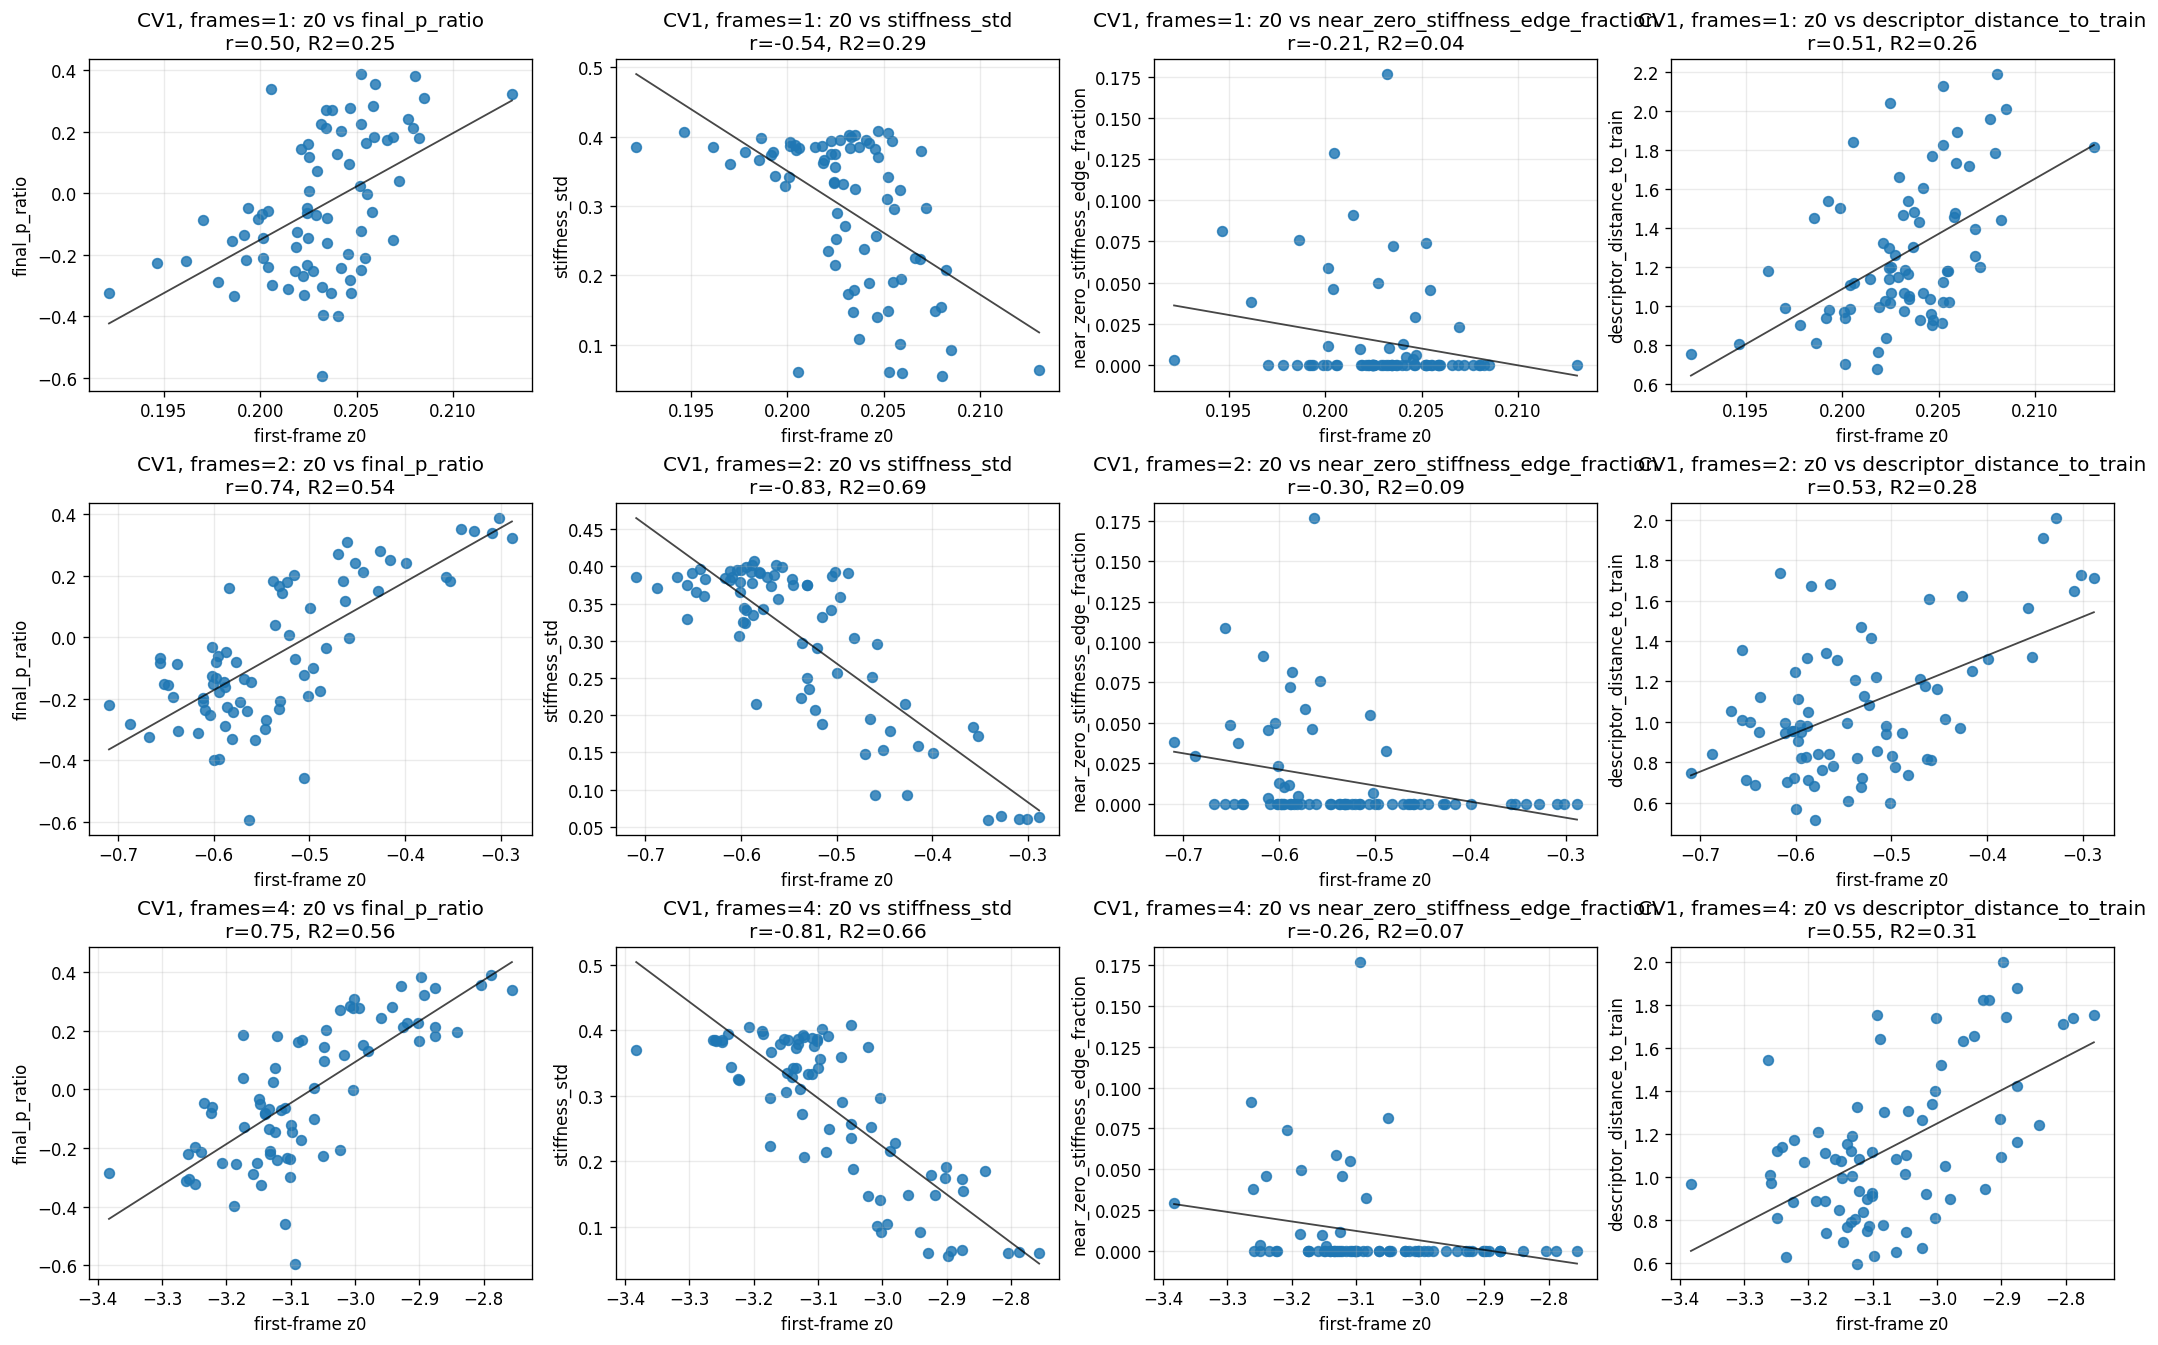

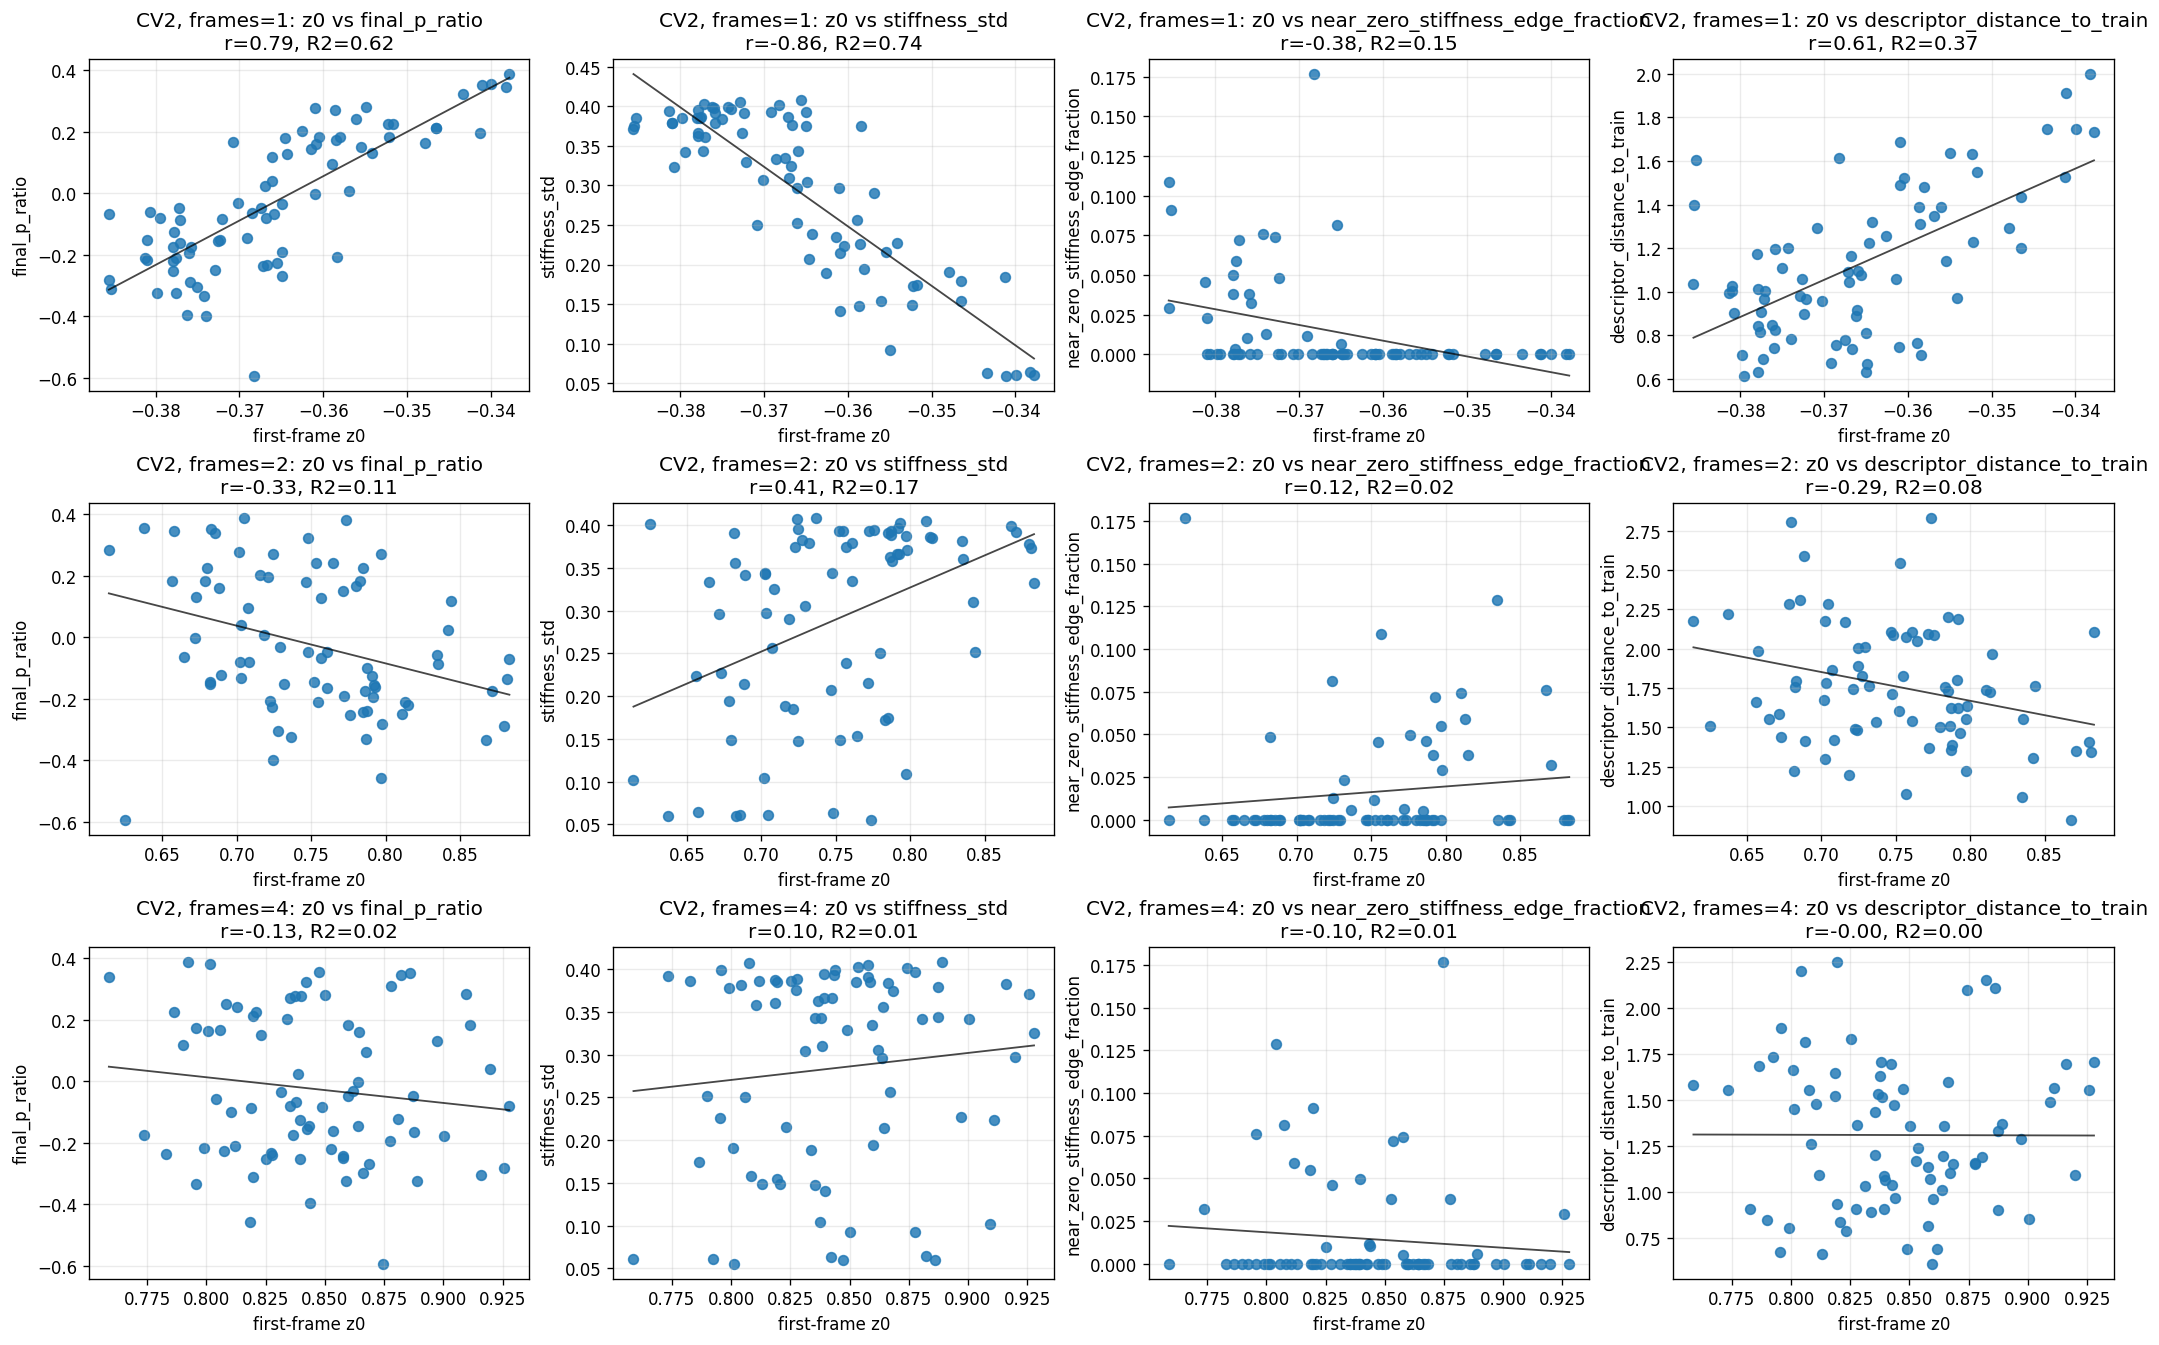

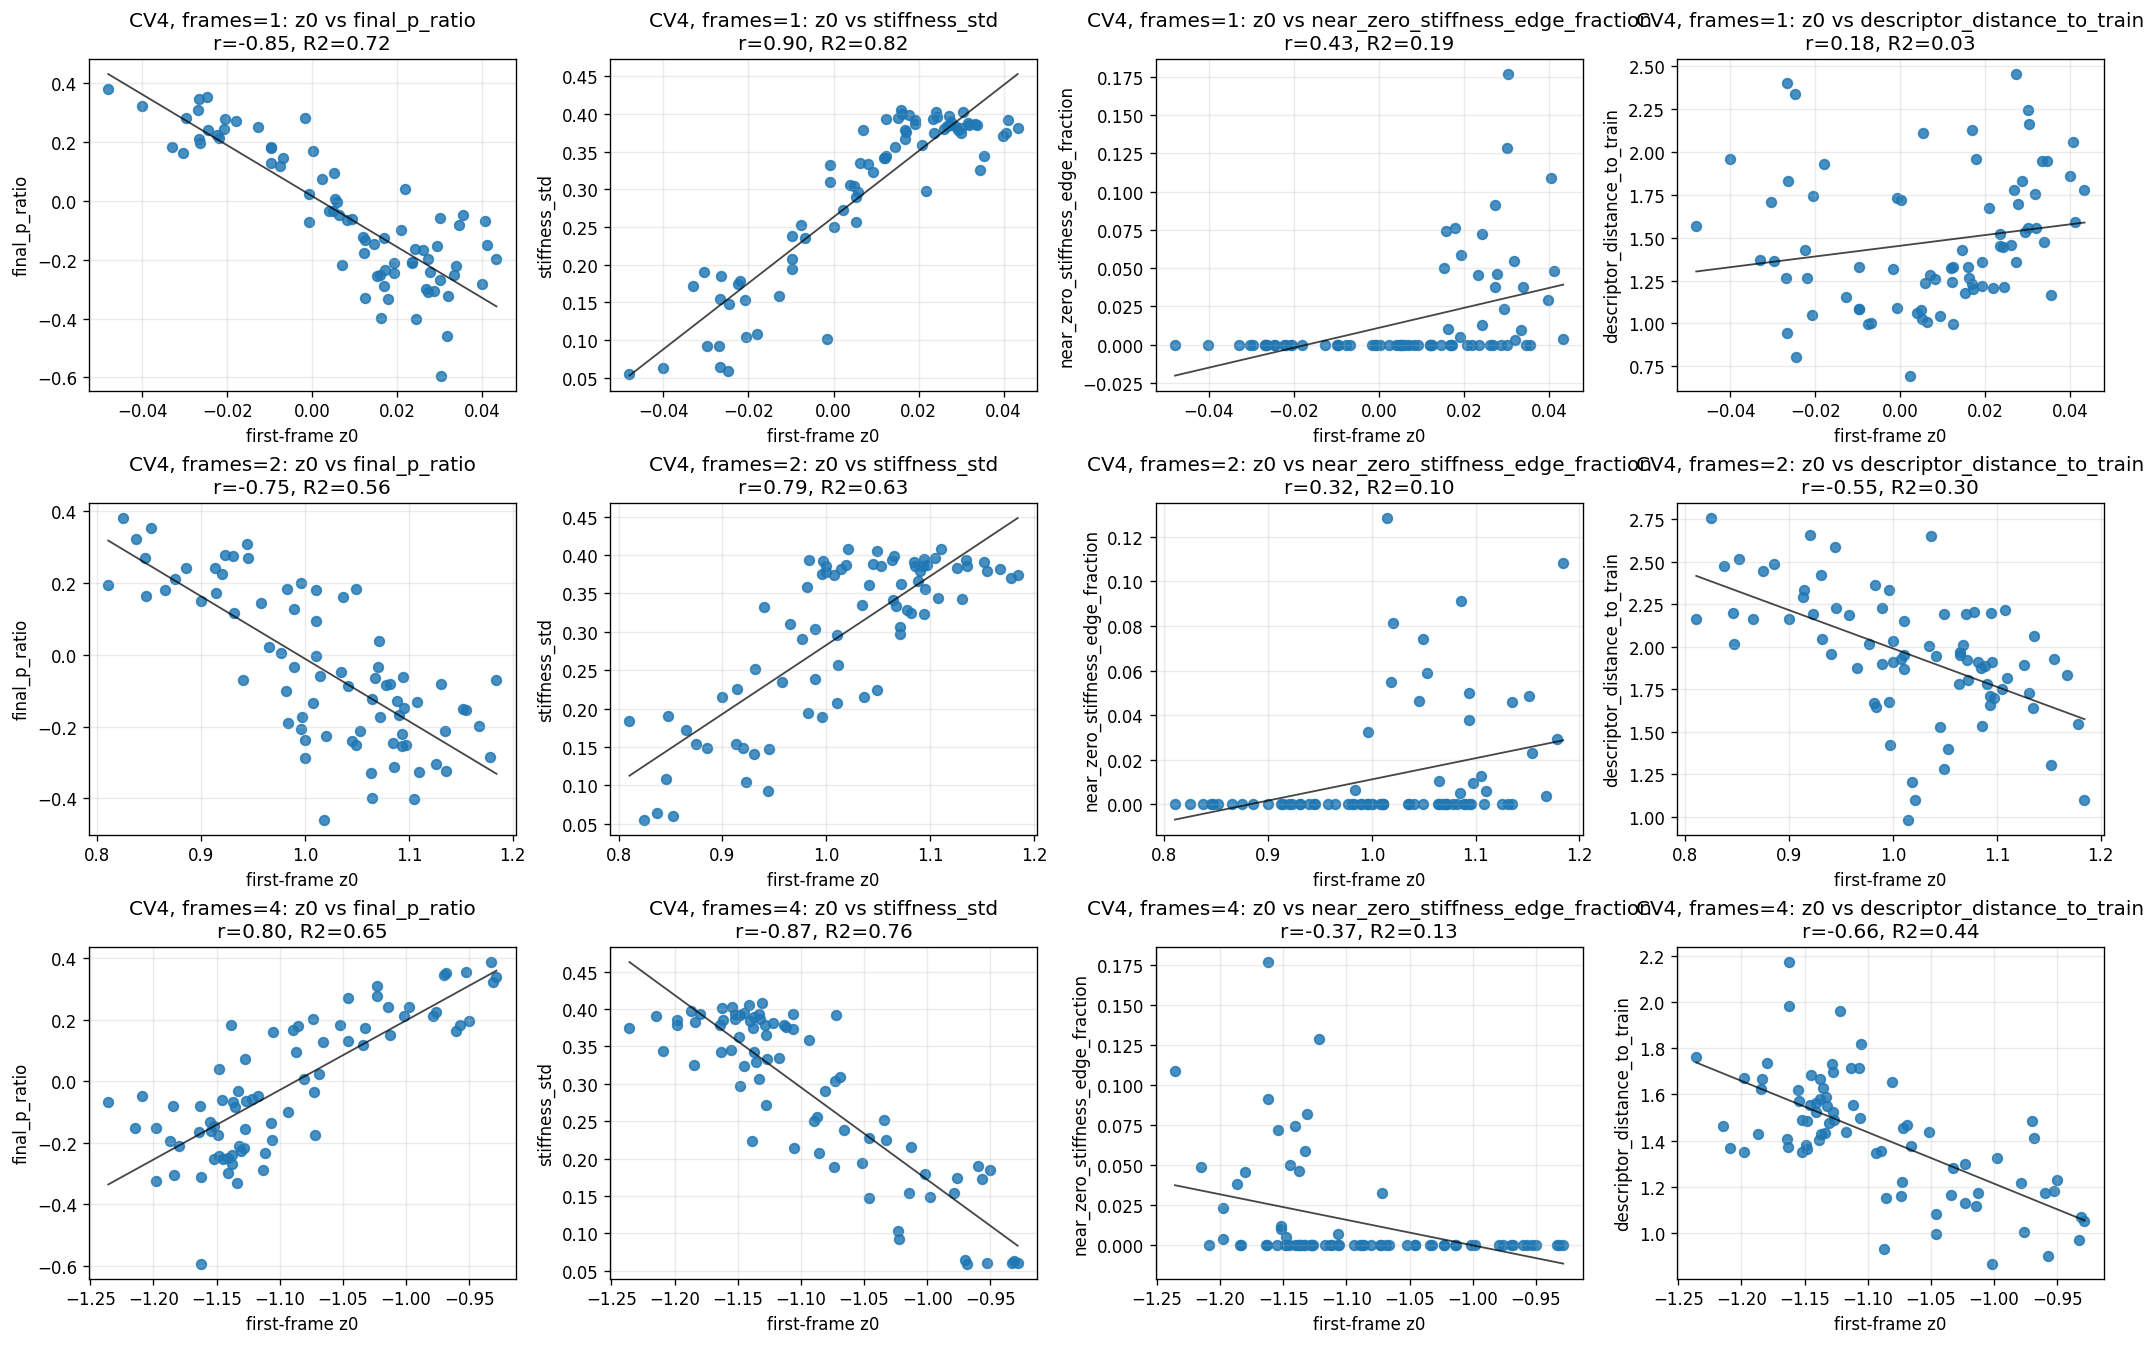

In [ ]:
plot_targets = ['final_p_ratio', 'stiffness_std', 'near_zero_stiffness_edge_fraction', 'descriptor_distance_to_train']
for latent_dim in latent_dims:
    fig, axes = plt.subplots(len(train_frame_counts), len(plot_targets), figsize=(4.4 * len(plot_targets), 3.7 * len(train_frame_counts)), squeeze=False, constrained_layout=True)
    for row_idx, train_frames in enumerate(train_frame_counts):
        group = first_frame_latent_df[
            first_frame_latent_df['split'].eq('test')
            & first_frame_latent_df['latent_dim'].eq(latent_dim)
            & first_frame_latent_df['repeat'].eq(1)
            & first_frame_latent_df['train_networks'].eq(1)
            & first_frame_latent_df['train_frames_per_network'].eq(train_frames)
        ].copy()
        for ax, y_col in zip(axes[row_idx], plot_targets):
            if y_col not in group.columns:
                ax.axis('off')
                continue
            plot_df = group[['z0', y_col]].replace([np.inf, -np.inf], np.nan).dropna()
            ax.scatter(plot_df['z0'], plot_df[y_col], s=34, alpha=0.82)
            if len(plot_df) >= 2 and plot_df['z0'].nunique() > 1:
                coef = np.polyfit(plot_df['z0'], plot_df[y_col], deg=1)
                xs = np.linspace(float(plot_df['z0'].min()), float(plot_df['z0'].max()), 100)
                ax.plot(xs, coef[0] * xs + coef[1], color='black', lw=1.1, alpha=0.72)
            r = pearson_r(plot_df['z0'], plot_df[y_col])
            ax.set_title(f'CV{latent_dim}, frames={train_frames}: z0 vs {y_col}\nr={r:.2f}, R2={r*r:.2f}' if np.isfinite(r) else f'z0 vs {y_col}')
            ax.set_xlabel('first-frame z0')
            ax.set_ylabel(y_col)
            ax.grid(alpha=0.25)
    plt.show()


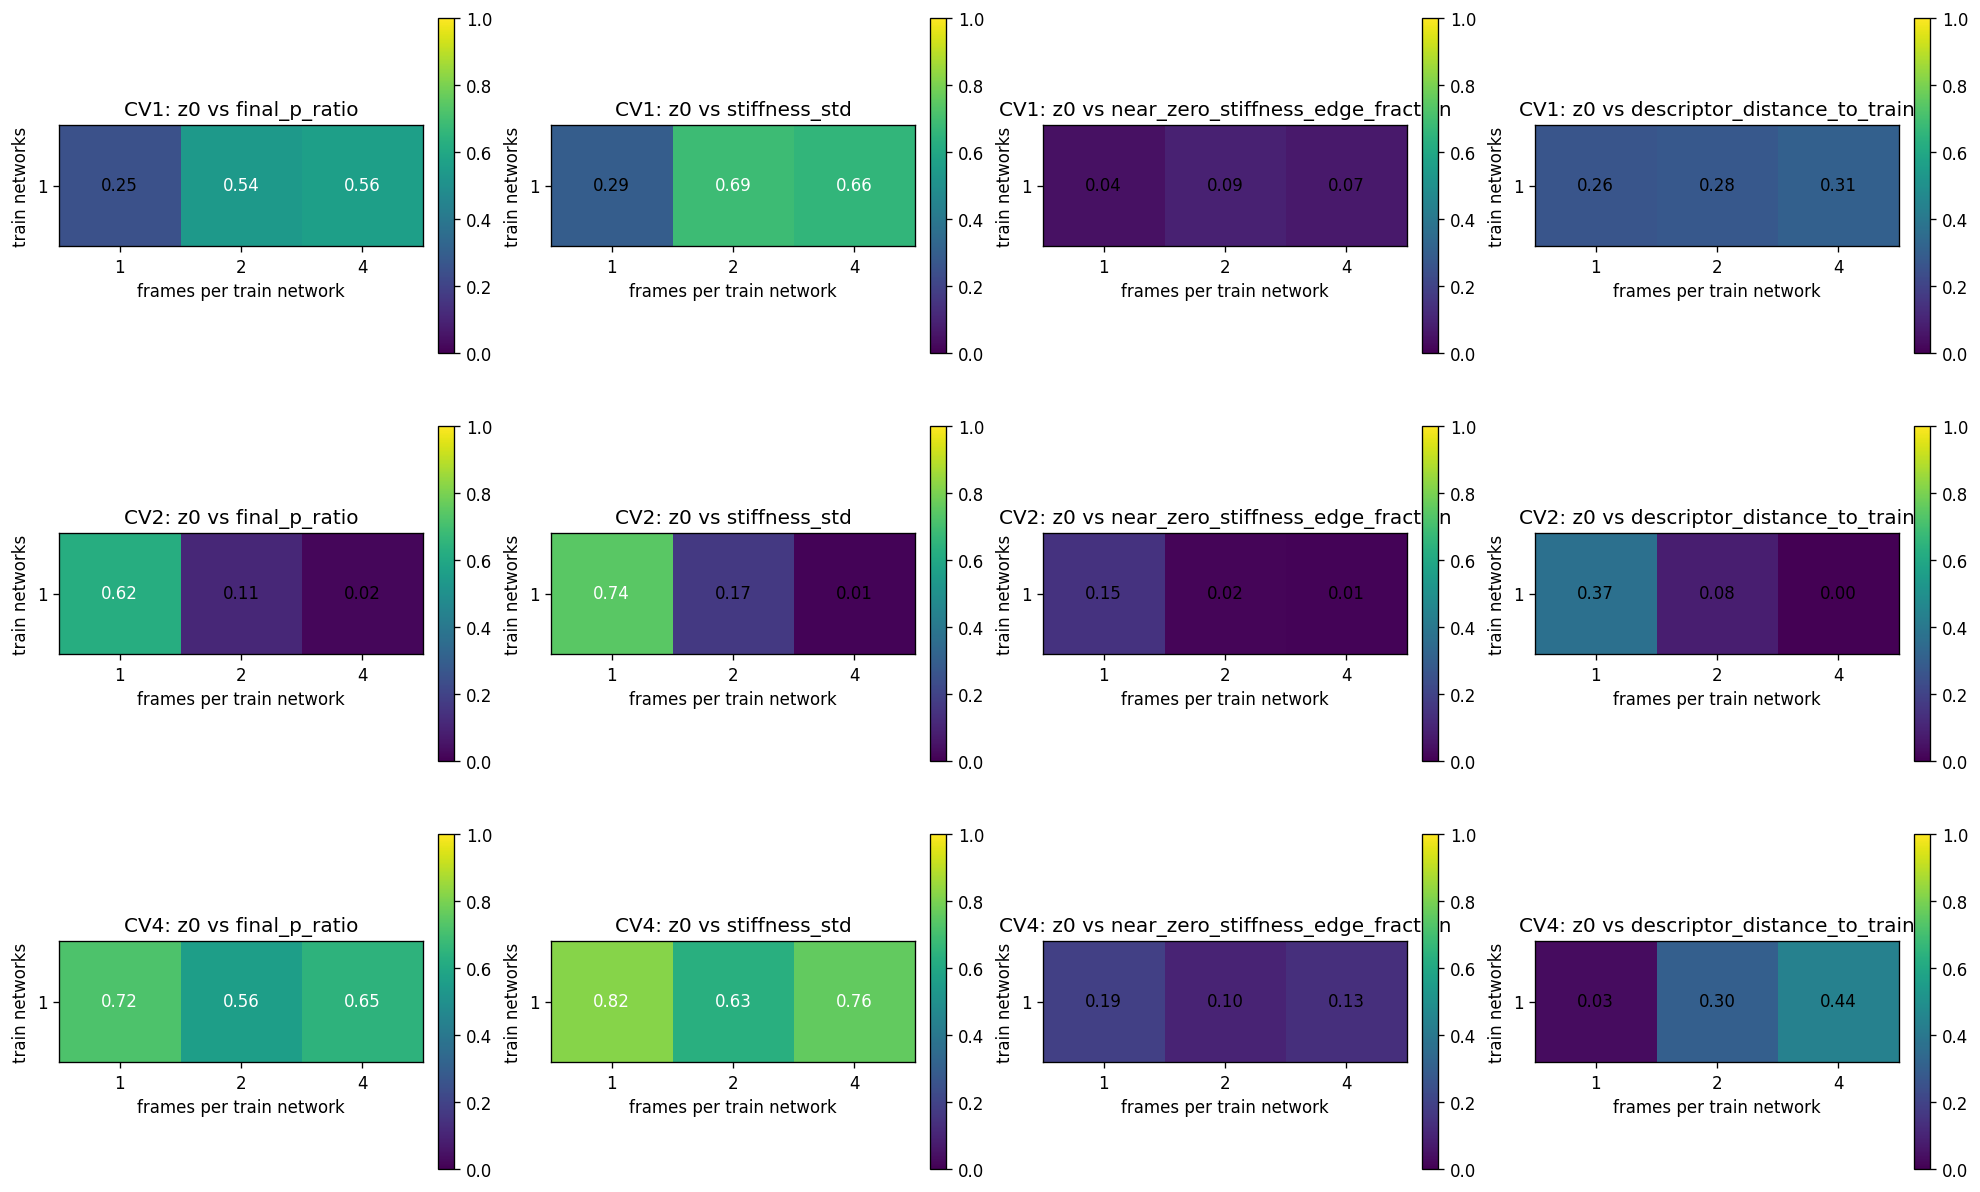

In [ ]:
# Compact heatmaps for what z0 tracks as training frames increase.
heat_targets = ['final_p_ratio', 'stiffness_std', 'near_zero_stiffness_edge_fraction', 'descriptor_distance_to_train']
fig, axes = plt.subplots(len(latent_dims), len(heat_targets), figsize=(4.1 * len(heat_targets), 3.4 * len(latent_dims)), squeeze=False, constrained_layout=True)
for row_idx, latent_dim in enumerate(latent_dims):
    for col_idx, target in enumerate(heat_targets):
        ax = axes[row_idx, col_idx]
        plot_df = corr_df[
            corr_df['split'].eq('test')
            & corr_df['latent_dim'].eq(latent_dim)
            & corr_df['signal'].eq('z0')
            & corr_df['target'].eq(target)
        ]
        if plot_df.empty:
            ax.axis('off')
            continue
        heat = plot_df.pivot(index='train_networks', columns='train_frames_per_network', values='corr_r2')
        im = ax.imshow(heat.to_numpy(dtype=float), vmin=0, vmax=1, cmap='viridis')
        ax.set_xticks(range(len(heat.columns)), heat.columns)
        ax.set_yticks(range(len(heat.index)), heat.index)
        ax.set_xlabel('frames per train network')
        ax.set_ylabel('train networks')
        ax.set_title(f'CV{latent_dim}: z0 vs {target}')
        for i, idx in enumerate(heat.index):
            for j, frame_count in enumerate(heat.columns):
                val = heat.loc[idx, frame_count]
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if val > 0.45 else 'black')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


In [ ]:
export_dir = run_dir / 'exports'
export_dir.mkdir(parents=True, exist_ok=True)
all_history_df.to_csv(export_dir / 'ae_history.csv', index=False)
split_info_df.to_csv(export_dir / 'split_info.csv', index=False)
first_frame_latent_df.to_csv(export_dir / 'first_frame_latents.csv', index=False)
trajectory_progress_latent_df.to_csv(export_dir / 'trajectory_progress_latents.csv', index=False)
corr_df.to_csv(export_dir / 'z_descriptor_correlations.csv', index=False)
trajectory_progress_corr_df.to_csv(export_dir / 'z_trajectory_progress_correlations.csv', index=False)
trajectory_progress_summary_df.to_csv(export_dir / 'z_trajectory_progress_summary.csv', index=False)
readout_summary_df.to_csv(export_dir / 'z_pratio_readout.csv', index=False)
linear_combo_readout_df.to_csv(export_dir / 'z_linear_combo_pratio_readout.csv', index=False)
null_df.to_csv(export_dir / 'z_pratio_permutation_null.csv', index=False)
partial_corr_df.to_csv(export_dir / 'z_pratio_partial_correlations.csv', index=False)
latent_vs_descriptor_df.to_csv(export_dir / 'latent_vs_descriptor_pratio_rank.csv', index=False)
print(f'wrote exports to {export_dir}')


wrote exports to results/rep1_net1_latent_probe/exports
